# ResNet50 — Experiment 2: Frozen + Data Augmentation
Same frozen backbone as Exp1 but adds augmentation to improve generalization.

In [1]:
import os, re, json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

TRAIN_DIR = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/train"
VAL_DIR   = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/val"
TEST_DIR  = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/test"

CLASS_NAMES = [
    'Angular Leafspot',
    'Anthracnose Fruit Rot',
    'Blossom Blight',
    'Gray Mold',
    'Leaf Spot',
    'Powdery Mildew Fruit',
    'Powdery Mildew Leaf'
]

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-3
SEED       = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
print('Setup done.')

2026-03-11 02:03:15.167094: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773194595.373864      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773194595.421069      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773194595.802973      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773194595.803018      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773194595.803022      24 computation_placer.cc:177] computation placer alr

Setup done.


In [2]:
# ── Load Labels from JSON ───────────────────────────────
def load_split(folder):
    data = []
    for f in os.listdir(folder):
        if not f.lower().endswith('.jpg'):
            continue
        img_path  = os.path.join(folder, f)
        json_path = img_path.replace('.jpg', '.json')
        label = None
        if os.path.exists(json_path):
            try:
                with open(json_path) as jf:
                    ann = json.load(jf)
                shapes = ann.get('shapes', [])
                if shapes:
                    label = shapes[0].get('label', None)
            except:
                pass
        if not label:
            name = os.path.splitext(f)[0]
            label = re.sub(r'\d+$', '', name).strip()
        data.append([img_path, label])
    return pd.DataFrame(data, columns=['path', 'label'])

train_df = load_split(TRAIN_DIR)
val_df   = load_split(VAL_DIR)
test_df  = load_split(TEST_DIR)

label2idx   = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

for df in (train_df, val_df, test_df):
    df['label_idx'] = df['label'].map(label2idx)

weights = compute_class_weight('balanced',
                                classes=np.arange(NUM_CLASSES),
                                y=train_df['label_idx'].values)
class_weight_dict = dict(enumerate(weights))
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 1450 | Val: 307 | Test: 743


In [3]:
# ── tf.data Pipeline ────────────────────────────────────
preprocess = tf.keras.applications.resnet50.preprocess_input

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess(img)
    return img, label

def make_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['path'].values, df['label_idx'].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)
print('Datasets ready.')

I0000 00:00:1773194636.267630      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773194636.273299      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets ready.


In [4]:
# ── Build Model: Frozen ResNet50 + Augmentation ─────────
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
], name='augmentation')

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # Still frozen

inputs  = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x       = data_augmentation(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_exp2 = models.Model(inputs, outputs, name='ResNet50_Exp2')
model_exp2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_exp2.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_Exp2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │        14,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,610,247 (90.07 MB)

 Trainable params: 18,439 (72.03 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [5]:
# ── Train ───────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1),
]

history2 = model_exp2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/20


I0000 00:00:1773194651.529514      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


46/46 ━━━━━━━━━━━━━━━━━━━━ 24s 233ms/step - accuracy: 0.4268 - loss: 1.8261 - val_accuracy: 0.8339 - val_loss: 0.5268 - learning_rate: 0.0010
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - accuracy: 0.8354 - loss: 0.4764 - val_accuracy: 0.8469 - val_loss: 0.4346 - learning_rate: 0.0010
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.8817 - loss: 0.4245 - val_accuracy: 0.8697 - val_loss: 0.4061 - learning_rate: 0.0010
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.8915 - loss: 0.3595 - val_accuracy: 0.9055 - val_loss: 0.3026 - learning_rate: 0.0010
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - accuracy: 0.8965 - loss: 0.2851 - val_accuracy: 0.9121 - val_loss: 0.2430 - learning_rate: 0.0010
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 158ms/step - accuracy: 0.9078 - loss: 0.2580 - val_accuracy: 0.9251 - val_loss: 0.2253 - learning_rate: 0.0010
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.9355 - loss: 0.2035 - val_accura

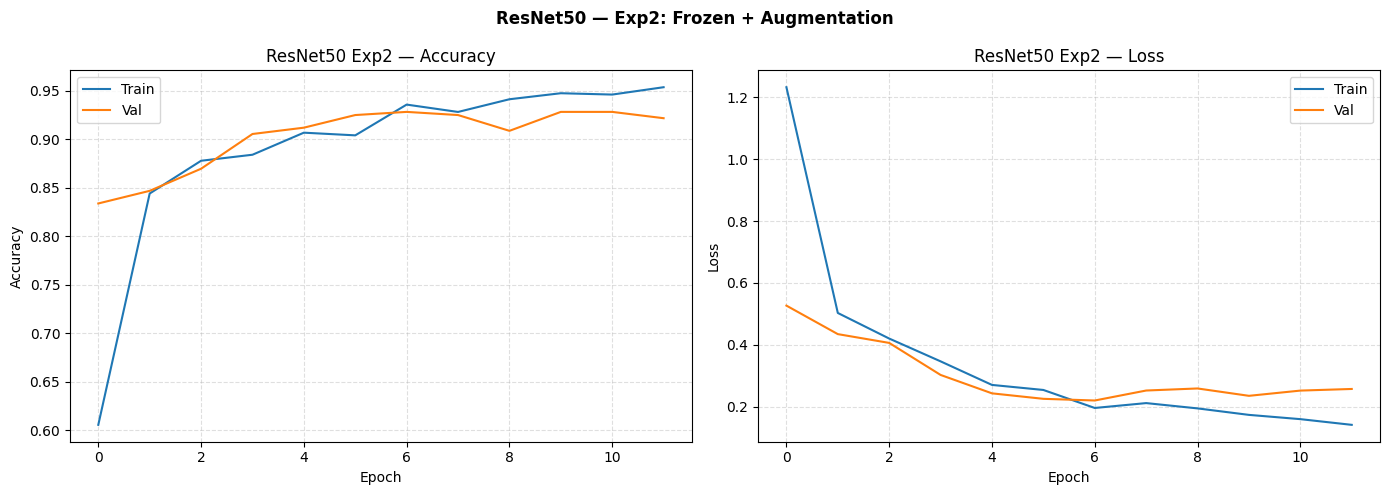

In [6]:
# ── Training Curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history2.history['accuracy'],     label='Train')
axes[0].plot(history2.history['val_accuracy'], label='Val')
axes[0].set_title('ResNet50 Exp2 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.4)

axes[1].plot(history2.history['loss'],     label='Train')
axes[1].plot(history2.history['val_loss'], label='Val')
axes[1].set_title('ResNet50 Exp2 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('ResNet50 — Exp2: Frozen + Augmentation', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/resnet_exp2_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── Evaluate on Test Set ────────────────────────────────
test_loss, test_acc = model_exp2.evaluate(test_ds, verbose=0)
print(f'[ResNet50 Exp2] Test Loss    : {test_loss:.4f}')
print(f'[ResNet50 Exp2] Test Accuracy: {test_acc:.4f}')

y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_prob = model_exp2.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

print('\n[ResNet50 Exp2] Classification Report:')
print(classification_report(y_true, y_pred,
      target_names=CLASS_NAMES, digits=4, zero_division=0))

[ResNet50 Exp2] Test Loss    : 0.3628
[ResNet50 Exp2] Test Accuracy: 0.8735
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 202ms/step

[ResNet50 Exp2] Classification Report:
                       precision    recall  f1-score   support

     Angular Leafspot     0.8375    0.9116    0.8730       147
Anthracnose Fruit Rot     0.5946    0.6471    0.6197        34
       Blossom Blight     1.0000    0.9839    0.9919        62
            Gray Mold     0.8354    0.9448    0.8867       145
            Leaf Spot     0.9549    0.7888    0.8639       161
 Powdery Mildew Fruit     0.5789    0.5116    0.5432        43
  Powdery Mildew Leaf     0.9733    0.9669    0.9701       151

             accuracy                         0.8735       743
            macro avg     0.8249    0.8221    0.8212       743
         weighted avg     0.8776    0.8735    0.8727       743



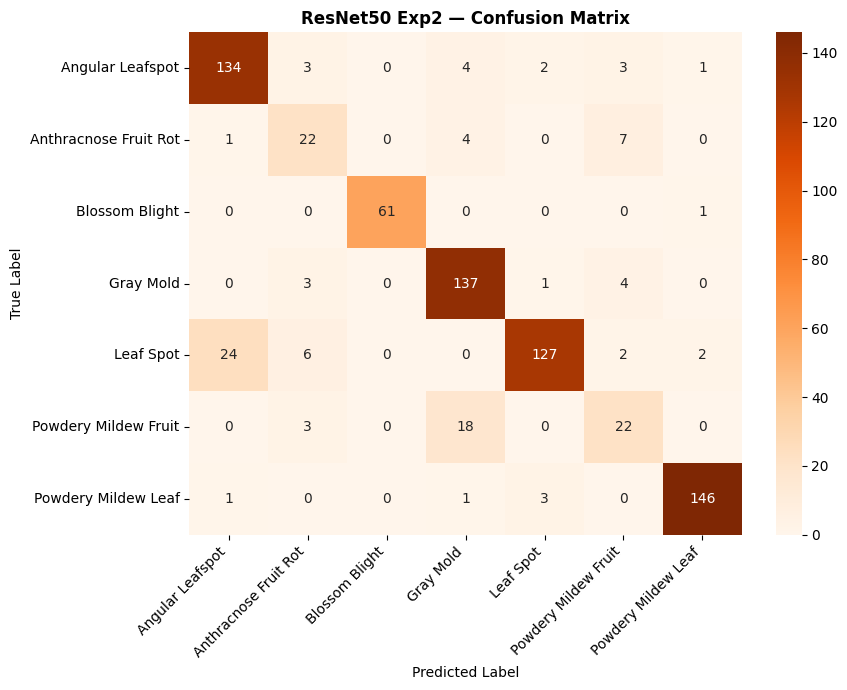

In [8]:
# ── Confusion Matrix ────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('ResNet50 Exp2 — Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/resnet_exp2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Save Model + Results CSV ────────────────────────────
model_exp2.save('/kaggle/working/resnet_exp2.keras')

exp2_results = {
    'experiment' : 'Exp2 - Frozen+Aug',
    'model'      : 'ResNet50',
    'test_acc'   : round(float(test_acc), 4),
    'test_loss'  : round(float(test_loss), 4),
    'f1_weighted': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    'precision'  : round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    'recall'     : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
}
pd.DataFrame([exp2_results]).to_csv('/kaggle/working/resnet_exp2_results.csv', index=False)
print('Model and results saved!')
print(exp2_results)

Model and results saved!
{'experiment': 'Exp2 - Frozen+Aug', 'model': 'ResNet50', 'test_acc': 0.8735, 'test_loss': 0.3628, 'f1_weighted': 0.8727, 'precision': 0.8776, 'recall': 0.8735}
